# Applied Data Science (MAST30034) Project 1

##### Analyse how weather affects income for taxi drivers based on fare amount per hour, ignoring uncontrolled tip feature and cost features that add to the total amount but does not go to the drivers income (e.g. tax and charges).

## Importing and Cleaning Data

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder.appName("Project1")
    .config("spark.driver.memory", "6g")
    .config("spark.executor.memory", "6g")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)
sdf_green = spark.read.parquet('data/project1data_green/')
sdf_yellow = spark.read.parquet('data/project1data_yellow/')
sdf_yellow = sdf_yellow.withColumnRenamed('tpep_pickup_datetime', 'pickup_datetime') \
                       .withColumnRenamed('tpep_dropoff_datetime', 'dropoff_datetime')
sdf_green = sdf_green.withColumnRenamed('lpep_pickup_datetime', 'pickup_datetime') \
                     .withColumnRenamed('lpep_dropoff_datetime', 'dropoff_datetime')

# Find the common columns between the two dataframes
common_cols = list(set(sdf_green.columns).intersection(sdf_yellow.columns))
sdf_green_clean = sdf_green.select(common_cols)
sdf_yellow_clean = sdf_yellow.select(common_cols)

sdf_taxi = sdf_green_clean.union(sdf_yellow_clean) # Merge data

# Drop the columns that are not needed for the analysis
sdf_taxi = sdf_taxi.drop('tip_amount', 'tolls_amount', 'improvement_surcharge', 'passenger_count',
                         'congestion_surcharge', 'extra', 'mta_tax', 'store_and_fwd_flag', 'VendorID',
                         'payment_type', 'DOLocationID', 'cbd_congestion_fee',
                         'airport_fee', 'trip_type', 'total_amount')

sdf_taxi.count()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/30 18:28:59 WARN Utils: Your hostname, MacsPC, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/08/30 18:29:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/30 18:29:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


23563536

In [3]:
# Load weather csv and create column with same structure as pickup_hour in sdf_taxi for merging
sdf_weather = spark.read.csv(
    'data/project1data_weather/',
    header=True,
    inferSchema=True
)

sdf_weather = sdf_weather.withColumn("month_str", F.lpad(F.col("month").cast("string"), 2, "0")) \
    .withColumn("day_str", F.lpad(F.col("day").cast("string"), 2, "0")) \
    .withColumn("hour_str", F.lpad(F.col("hour").cast("string"), 2, "0"))

sdf_weather = sdf_weather.withColumn(
    "weather_hour",
    F.to_timestamp(
        F.concat_ws(
            " ",
            F.concat_ws("-", F.col("year"), F.col("month_str"), F.col("day_str")),
            F.concat_ws(":", F.col("hour_str"), F.lit("00"), F.lit("00"))
        ),
        "yyyy-MM-dd HH:mm:ss"
    )
)
needed_cols = ["weather_hour", "coco"]
sdf_weather = sdf_weather.select(needed_cols)
sdf_weather = sdf_weather.select(["weather_hour"] + [c for c in sdf_weather.columns if c != "weather_hour"])


## Preprocessing
### Filtering with Feature Engineering

In [4]:
""" 
Remove unreasonable rows based on restrictions on the pickup_datetime, fare_amount, 
PULocationID, trip_distance, trip_duration, dropoff_datetime, and speed
"""
sdf_taxi = sdf_taxi.filter((sdf_taxi.pickup_datetime >= '2025-12-01') & 
                           (sdf_taxi.pickup_datetime < '2026-06-01'))
sdf_taxi = sdf_taxi.filter(sdf_taxi.fare_amount >= 3)
sdf_taxi = sdf_taxi.filter((sdf_taxi.PULocationID >= 1) & 
                           (sdf_taxi.PULocationID <= 263))
sdf_taxi = sdf_taxi.filter(sdf_taxi.trip_distance > 0)

# After geospatial analysis, we found that negotiated trips distort the data
sdf_taxi = sdf_taxi.filter(sdf_taxi.RatecodeID != 5)
sdf_taxi = sdf_taxi.drop('RatecodeID')

# Create new feature: trip duration in minutes
sdf_taxi = sdf_taxi.withColumn(
    "trip_duration",
    (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")) / 60
)

sdf_taxi = sdf_taxi.filter(sdf_taxi.trip_duration > 0)
sdf_taxi = sdf_taxi.drop('dropoff_datetime')

# Create new feature: speed in miles/hour
sdf_taxi = sdf_taxi.withColumn(
    "speed",
    (F.col("trip_distance") / (F.col("trip_duration") / 60))
)
sdf_taxi = sdf_taxi.filter((sdf_taxi.speed <= 65))


### Remove Outliers

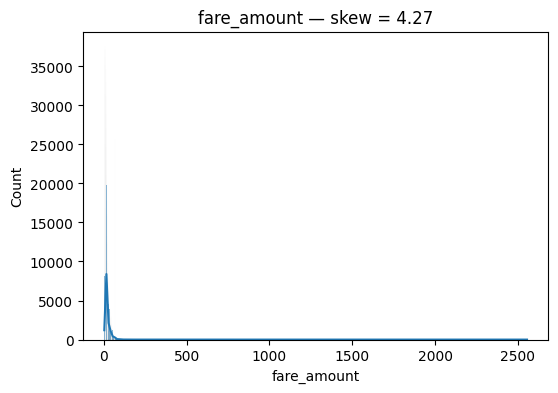

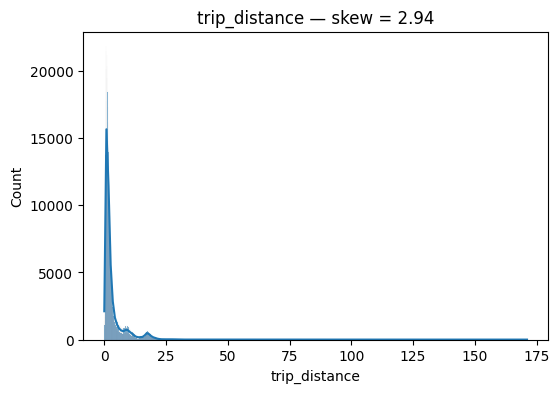

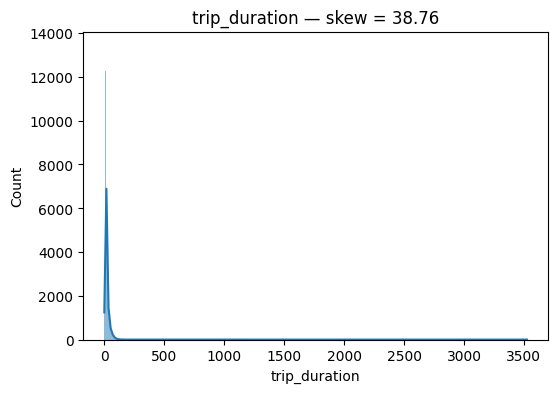

In [5]:
# Check the skewness of the columns w/out an upper bound
numeric_cols = ["fare_amount", "trip_distance", "trip_duration"]

skew_df = sdf_taxi.select([
    F.skewness(c).alias(c) for c in numeric_cols
])
skew_vals = skew_df.collect()[0].asDict()
pdf = sdf_taxi.select(numeric_cols).sample(0.05).toPandas()

import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(pdf[col], kde=True)
    plt.title(f"{col} — skew = {skew_vals[col]:.2f}")
    plt.show()


In [6]:
"""
Extreme outliers in trip_duration
Remove outliers using z-score
"""
sdf_taxi = sdf_taxi.withColumn("log_duration", F.log1p("trip_duration"))

stats = sdf_taxi.agg(
    F.mean("log_duration").alias("mean"),
    F.stddev("log_duration").alias("std")
).collect()[0]

mu = stats["mean"]
sigma = stats["std"]

sdf_taxi = sdf_taxi.withColumn(
    "z_score",
    (F.col("log_duration") - F.lit(mu)) / F.lit(sigma)
)
sdf_taxi = sdf_taxi.filter(F.col("z_score") < 3)
sdf_taxi = sdf_taxi.drop("log_duration", "z_score")

In [7]:
# Create new feature: fare per minute
sdf_taxi = sdf_taxi.withColumn("fare_per_minute", F.col("fare_amount") / F.col("trip_duration"))

### Create Subset for Sampling

In [8]:
# Round the pickup_datetime to nearest hour and set it as first column
sdf_taxi = sdf_taxi.withColumn("pickup_hour", F.date_trunc("hour", F.col("pickup_datetime"))).orderBy("pickup_hour")
sdf_taxi = sdf_taxi.drop("pickup_datetime")
cols = ["pickup_hour"] + [c for c in sdf_taxi.columns if c != "pickup_hour"]
sdf_taxi = sdf_taxi.select(cols)
sdf_taxi.show(5)

+-------------------+-----------+-------------+------------+------------------+------------------+------------------+
|        pickup_hour|fare_amount|trip_distance|PULocationID|     trip_duration|             speed|   fare_per_minute|
+-------------------+-----------+-------------+------------+------------------+------------------+------------------+
|2025-12-01 00:00:00|        4.4|         0.37|         223|2.1166666666666667|10.488188976377954|2.0787401574803153|
|2025-12-01 00:00:00|       28.2|          1.7|          21|             33.65| 3.031203566121843|0.8380386329866271|
|2025-12-01 00:00:00|       38.7|          6.7|          11| 41.53333333333333|  9.67897271268058|0.9317817014446229|
|2025-12-01 00:00:00|       22.6|         4.59|         180|17.466666666666665|15.767175572519085|1.2938931297709926|
|2025-12-01 00:00:00|        5.8|         0.43|         129|               3.7| 6.972972972972973|1.5675675675675675|
+-------------------+-----------+-------------+---------

In [9]:
# Create stratified sample of the cleaned df for analysis and visualisation
zone_counts = sdf_taxi.groupBy("PULocationID").count()

# Aim for 50 samples/zone, take all if samples < 50
target_n = 50
zone_pdf = zone_counts.toPandas()
zone_pdf["fraction"] = (target_n / zone_pdf["count"]).clip(upper=1.0)

fractions = dict(zip(zone_pdf.PULocationID, zone_pdf.fraction))
strat_sdf = sdf_taxi.sampleBy("PULocationID", fractions, seed=42)

# Save stratified sample
strat_sdf.write.mode("overwrite").parquet("data/cleaned_taxi_data.parquet")

## Geopspatial Visualisation and Analysis

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import geopandas as gpd
import pandas as pd
import folium
import numpy as np

spark = (
    SparkSession.builder.appName("Project1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

In [11]:
# Load in shapefile and taxi zone lookup
sf = gpd.read_file('data/taxi_zones/taxi_zones.shp')
zones = pd.read_csv('data/taxi_zones/taxi+_zone_lookup.csv')

# Read in the 5% sample of the cleaned dataframe with pandas
sample_sdf = spark.read.parquet('data/cleaned_taxi_data.parquet')
sample_pdf = sample_sdf.select("PULocationID", "fare_per_minute").toPandas()

In [12]:
# Convert geometry column to the same coordinate system as the shapefile
sf['geometry'] = sf['geometry'].to_crs("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs")
gdf = gpd.GeoDataFrame(
    pd.merge(zones, sf, on='LocationID', how='inner')
)

geoJSON = gdf[['LocationID', 'geometry']].drop_duplicates('LocationID').to_json()


In [13]:
# Calculate the mean fare_per_minute and count of trips for each PULocationID
means = (
    sample_pdf.groupby("PULocationID")["fare_per_minute"]
    .mean()
    .reset_index()
)

counts = (
    sample_pdf.groupby("PULocationID")
    .size()
    .reset_index(name="n")
)

merged = means.merge(counts, on="PULocationID")
merged = merged[merged["n"] >= 30]
merged = means.merge(
    gdf[["LocationID", "geometry"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).drop("LocationID", axis=1)
merged_gdf = gpd.GeoDataFrame(merged)

# Scale w/log transformation to reduce skewness when colouring the map
merged_gdf["fare_log"] = np.log1p(merged_gdf["fare_per_minute"])

In [14]:
m = folium.Map(
    location=[40.66, -73.94], 
    tiles="Stamen Terrain", 
    attr="Map tiles by Stamen Design, under CC BY 3.0. Data by OpenStreetMap.", 
    zoom_start=10
)

c = folium.Choropleth(
    geo_data=geoJSON,
    name='choropleth',
    data=merged_gdf.reset_index(),
    columns=["PULocationID", "fare_log"], # fare now logged
    key_on='properties.LocationID',
    fill_color='YlOrRd',
    nan_fill_color='black',
    legend_name='Log(Fare per Minute)'
)
c.add_to(m)
m.save("foliumChoroplethMap.html")

## Modelling

### Merge Taxi and Weather DFs

In [15]:
# Show distinct values in the 'coco' column of sdf_weather
sdf_weather.select("coco").distinct().orderBy("coco").show()

+----+
|coco|
+----+
|NULL|
|   1|
|   2|
|   3|
|   5|
|   7|
|   8|
|   9|
|  12|
|  13|
|  14|
|  15|
|  16|
|  17|
|  18|
|  21|
+----+



In [16]:
# Merge weather into the full cleaned taxi dataset
sdf_taxi = sdf_taxi.join(
    sdf_weather,
    sdf_taxi.pickup_hour == sdf_weather.weather_hour,
    how="left"
)


In [ ]:
# Define severity mapping
severity_map = {
    None: 0,                            # assume good
    1: 0, 2: 0, 3: 0,                   # good
    5: 1, 7: 1, 8: 1, 17: 1, 18: 1,     # poor
    9: 2, 12: 2, 14: 2, 15: 2, 21: 2,   # bad
    13: 3, 16: 3                        # severe
}

# Add severity column
severity_expr = F.create_map([F.lit(x) for kv in severity_map.items() for x in kv])
sdf_taxi = sdf_taxi.withColumn(
    "severity",
    F.coalesce(severity_expr[F.col("coco")], F.lit(0))
)


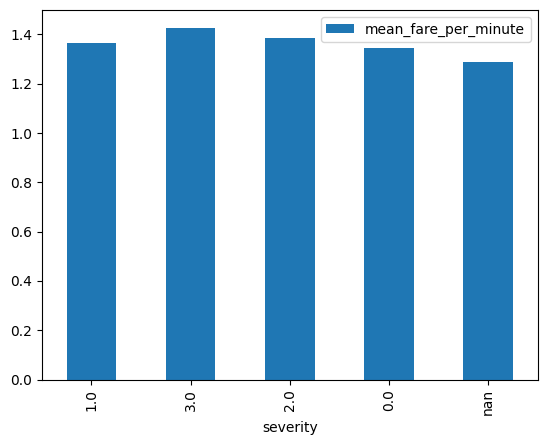

In [ ]:
# Compute mean fare/min per severity in PySpark
severity_means_sdf = sdf_taxi.groupBy("severity").agg(
    F.mean("fare_per_minute").alias("mean_fare_per_minute")
)
severity_means = severity_means_sdf.toPandas()
print(severity_means.columns)

# Plot
severity_means.plot.bar(
    x="severity",
    y="mean_fare_per_minute"
)
plt.show()

In [ ]:
model_sdf = sdf_taxi.select(
    "fare_per_minute",
    "PULocationID",
    "coco"
)
model_df = model_sdf.toPandas()

counts = model_df.groupby("PULocationID").size().reset_index(name="n")
model_df = model_df.merge(counts, on="PULocationID")
model_df = model_df[model_df["n"] >= 30]

import statsmodels.formula.api as smf

lm = smf.ols(
    "fare_per_minute ~ C(coco) + C(PULocationID)",
    data=model_df
).fit()

print(lm.summary())

### GroupBy (Aggregation)

## Sampling Data for Plotting

Whilst Spark is amazing at handling big data sets, it isn't a great idea to plot all of it. We suggest taking a maximum of 5% of records for the tutorial. 

You can up it to your requirements, but we recommend sticking to less than 1 million records per month for visualization purposes.

**Project 1 Checklist:**
- You have justified your sample size (i.e due to runtime, distribution of data, etc)
- You have justified your sampling method (i.e random, stratified, etc)
- You have detailed in your report that you have sampled for visualization purposes BUT your analysis still uses the full distribution of data
- You mention any issues that can potentially be caused by sampling (i.e biased visualisation if using random)

Remember, it is your responsibility as the student (future Data Scientist) to convince the tutor (your stakeholders) that your justifications and assumptions are correct!

We recommend you save every dataframe or aggregation as `parquet` so you don't keep running your notebook from top to bottom waiting 20 years for a result, or have so many variables and dataframes defined that you run out of memory for small transformations.

We strongly suggest you have a `code` folder in your Project 1 directory with the following structure:
- `preprocessing_notebook_part_1.ipynb`: outputs a structured parquet format and saves it.
- `preprocessing_notebook_part_2.ipynb`: reads in the output from above and does some aggregations and sampling before saving it.
- `data_analysis_xyz.ipynb`: conducts analysis on a single sample or aggregation from the output above.
- `data_analysis_abc.ipynb`: conducts analysis on another single sample or aggregation from the output above.
- `...`

This is a very basic version of what you call a "data pipeline" (or ETL pipeline, etc).